# Becoming one with the data

## Importing our drive and dataset folder

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import os

for dirpath, dirnames, filenames in os.walk("/content/drive/MyDrive/MRI2_split"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in \"{dirpath}\". ")

There are 2 directories and 0 images in "/content/drive/MyDrive/MRI2_split". 
There are 6 directories and 0 images in "/content/drive/MyDrive/MRI2_split/train". 
There are 0 directories and 945 images in "/content/drive/MyDrive/MRI2_split/train/MCI". 
There are 0 directories and 537 images in "/content/drive/MyDrive/MRI2_split/train/SMC". 
There are 0 directories and 1656 images in "/content/drive/MyDrive/MRI2_split/train/EMCI". 
There are 0 directories and 839 images in "/content/drive/MyDrive/MRI2_split/train/LMCI". 
There are 0 directories and 2828 images in "/content/drive/MyDrive/MRI2_split/train/CN". 
There are 0 directories and 1147 images in "/content/drive/MyDrive/MRI2_split/train/AD". 
There are 6 directories and 0 images in "/content/drive/MyDrive/MRI2_split/val". 
There are 0 directories and 300 images in "/content/drive/MyDrive/MRI2_split/val/AD". 
There are 0 directories and 300 images in "/content/drive/MyDrive/MRI2_split/val/CN". 
There are 0 directories and 300 images 

In [ ]:
#Defining paths and hyperparameters
train_dir = "/content/drive/MyDrive/MRI2_split/train/"
test_dir = "/content/drive/MyDrive/MRI2_split/val/"
IMG_SHAPE = (224,224,3)
BATCH_SIZE = 32


## Visualising the dataset

Please enter the target dataset split (e.g. train/val): train
Please enter the target class (e.g. AD, CN): AD
/content/drive/MyDrive/MRI2_split/train/AD/ADNI_100_S_6713_MR_Axial_3TE_T2_STAR__br_raw_20210901155328344_1_S1058826_I1487250-0375.jpg
(256, 256)


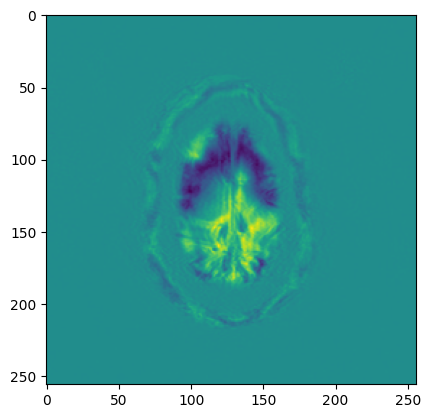

In [ ]:
#View a single image

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

target_dir = "/content/drive/MyDrive/MRI2_split/"
target_data = input("Please enter the target dataset split (e.g. train/val): ")
target_class=input("Please enter the target class (e.g. AD, CN): ")
target_path = target_dir + target_data + "/" + target_class
filenames = os.listdir(target_path)
target_img = target_path + "/" + random.sample(filenames, 1)[0]
print(target_img)

img = mpimg.imread(target_img)
print(img.shape)
plt.imshow(img);

In [ ]:
# #Viewing an image from one class each

# target_dir = "/content/drive/MyDrive/MRI2_split/"
# target_dataset = input('Please enter the dataset (train/val): ')
# target_path = target_dir + target_dataset
# target_images = random
# i=0
# plt.figure(figsize=(15,6))
# dirpath, dirnames, filenames in os.walk(target_path)


Please enter the dataset (train/val): train


('/content/drive/MyDrive/MRI2_split/val/SMC', [], False)

<Figure size 1500x600 with 0 Axes>

## Preparing the data



### Creating Data Loaders

In [2]:
#Setup data inputs

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training Images: ")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size = (224,224),
                                               batch_size = BATCH_SIZE,
                                               class_mode = "categorical")
print("Testing Images: ")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size = (224,224),
                                             batch_size = BATCH_SIZE,
                                             class_mode = "categorical")

Training Images: 


NameError: name 'train_dir' is not defined

### Setting up callbacks

In [3]:
#Create TensorBoard Callback function

import datetime
def tb_callback(dir_name, model_name):
  log_dir = dir_name + "/" +experiment_name + "/" + datetime.datetime.now().strftime("%Y%m&d")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

# Model


# VGG16

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16

## Loading VGG16 model
base_model = VGG16(weights="imagenet", include_top=False, input_shape= IMG_SHAPE)
base_model.trainable = False

base_model.summary()

58889256/58889256 [==============================] - 0s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                              

In [ ]:
# Creating
model_1 = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(6, activation ="softmax")

])
model_1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 6)                 3078      
                                                                 
Total params: 14717766 (56.14 MB)
Trainable params: 3078 (12.02 KB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


In [ ]:
# Compiling
model_1.compile(loss=tf.keras.losses.categorical_crossentropy,
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])
# Fitting
history_1=model_1.fit(train_data,
                      epochs=50,
                      steps_per_epoch=len(train_data),
                      validation_data=test_data,
                      validation_steps=len(test_data))

Epoch 1/50
249/249 [==============================] - 2720s 11s/step - loss: 1.5636 - accuracy: 0.3947 - val_loss: 1.7378 - val_accuracy: 0.2750
Epoch 2/50
249/249 [==============================] - 56s 224ms/step - loss: 1.4322 - accuracy: 0.4493 - val_loss: 1.6514 - val_accuracy: 0.2806
Epoch 3/50
249/249 [==============================] - 54s 218ms/step - loss: 1.3872 - accuracy: 0.4591 - val_loss: 1.6414 - val_accuracy: 0.2956
Epoch 4/50
249/249 [==============================] - 53s 213ms/step - loss: 1.3570 - accuracy: 0.4689 - val_loss: 1.5400 - val_accuracy: 0.3222
Epoch 5/50
249/249 [==============================] - 55s 220ms/step - loss: 1.3367 - accuracy: 0.4750 - val_loss: 1.5838 - val_accuracy: 0.3183
Epoch 6/50
249/249 [==============================] - 55s 222ms/step - loss: 1.3199 - accuracy: 0.4828 - val_loss: 1.5570 - val_accuracy: 0.3239
Epoch 7/50
249/249 [==============================] - 52s 210ms/step - loss: 1.3045 - accuracy: 0.4878 - val_loss: 1.5631 - val_ac

In [ ]:
# Saving
model_1.save("/content/drive/MyDrive/TLModels/VGG16")


## Evaluating model_1

In [ ]:
# Getting the true labels and predictions
import numpy as np
true_classes = test_data.classes
true_labels = test_data.class_indices
preds = model_1.predict(test_data, steps=len(test_data))
pred_classes = np.argmax(preds,axis=1)

In [ ]:
#Defining a function for plotting loss curves

def plot_loss_curves(history):
  train_acc = history.history["accuracy"]
  val_acc = history.history["val_accuracy"]
  train_loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  epochs = range(len(train_acc))
  plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
  plt.plot(epochs, val_acc, 'g', label='Validation Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.legend()
  plt.show()

  plt.figure()
  plt.plot(epochs, train_loss, 'b', label='Training Loss')
  plt.plot(epochs, val_loss, 'g', label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.show()

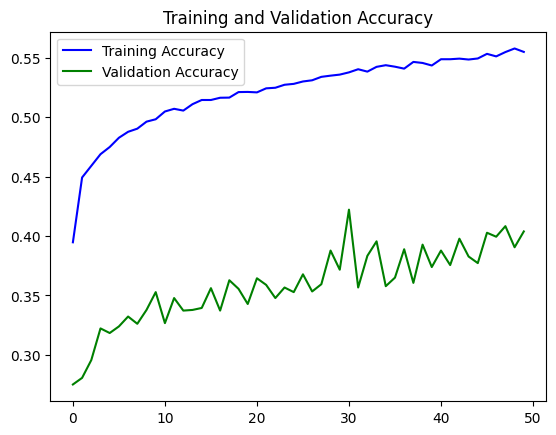

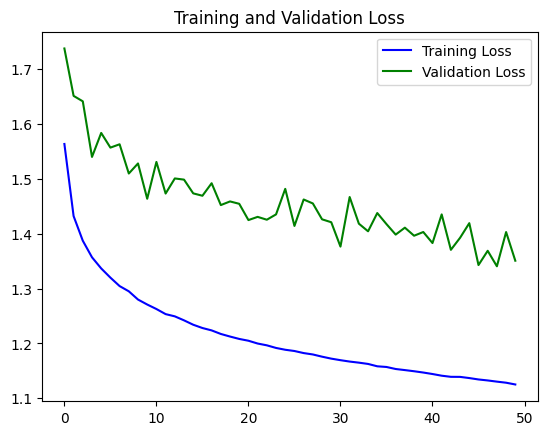

In [ ]:
plot_loss_curves(history_1)

## Confusion Matrix for model_1

In [ ]:
# Functionising the confusion_matrix call
def confusion_matrix(true_classes, pred_classes):
  from sklearn.metrics import confusion_matrix
  import seaborn as sns
  import numpy as np
  from matplotlib import pyplot as plt
  cm = confusion_matrix(true_classes,pred_classes)
  cm = np.array(cm)
  # Normalise
  cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
  fig, ax = plt.subplots(figsize=(5,4))

  sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=true_labels, yticklabels=true_labels, cmap="YlGnBu")
  plt.ylabel('Actual', fontsize=15)
  plt.xlabel('Predicted', fontsize=15)
  plt.show(block=False)

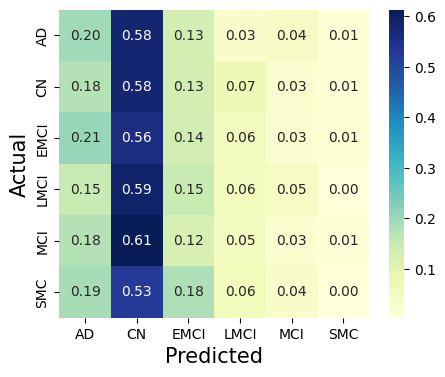

In [ ]:
confusion_matrix(true_classes, pred_classes)

## Classification Report for model_1

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(true_classes, pred_classes, target_names=true_labels))

              precision    recall  f1-score   support

          AD       0.18      0.20      0.19       300
          CN       0.17      0.58      0.26       300
        EMCI       0.16      0.14      0.15       300
        LMCI       0.17      0.06      0.09       300
         MCI       0.13      0.03      0.04       300
         SMC       0.07      0.00      0.01       300

    accuracy                           0.17      1800
   macro avg       0.15      0.17      0.12      1800
weighted avg       0.15      0.17      0.12      1800



# VGG19

In [ ]:
# Importing

from tensorflow.keras.applications.vgg19 import VGG19


# Loading VGG16 model
base_model19 = VGG19(weights="imagenet", include_top=False, input_shape = IMG_SHAPE)
base_model19.trainable=False
base_model19.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [ ]:
# Creating

model_2 = tf.keras.models.Sequential([
    base_model19,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(6, activation ="softmax")

])
model_2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 global_average_pooling2d_3  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_3 (Dense)             (None, 6)                 3078      
                                                                 
Total params: 20027462 (76.40 MB)
Trainable params: 3078 (12.02 KB)
Non-trainable params: 20024384 (76.39 MB)
_________________________________________________________________


In [ ]:
# Compiling

model_2.compile(loss=tf.keras.losses.categorical_crossentropy,
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])
# Fitting

history_2=model_2.fit(train_data,
                      epochs=50,
                      steps_per_epoch=len(train_data),
                      validation_data=test_data,
                      validation_steps=len(test_data))

Epoch 1/50
 49/249 [====>.........................] - ETA: 39s - loss: 1.6606 - accuracy: 0.3469

KeyboardInterrupt: 

In [ ]:
# Saving
model_2.save("/content/drive/MyDrive/TLModels/VGG19")

## Evaluating model_2

In [ ]:
plot_loss_curves(history_2)


AttributeError: 'NoneType' object has no attribute 'history'